<div class="usecase-title"><h2><b>Industry-Level Business Distribution and Employment Gap Analysis – Melbourne</b><h2></div>

<div class="usecase-authors"><b>Authored by:</b> Shinto Ayyamkulangara Shaji</div>

<div class="usecase-duration"><b>Duration:</b> 90 mins</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level:</b> Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills:</b> Python, pandas, matplotlib, seaborn, data wrangling</div>
</div>

<div class="usecase-section-header">Scenario</div>

As a city economic planner for the City of Melbourne, I want to understand which
industries and geographic areas have a mismatch between the number of businesses
operating and the number of people employed, so that I can identify underperforming
areas and potential growth opportunities to better direct economic development resources.

<div class="usecase-section-header">What this use case will teach you</div>

At the end of this use case you will:
- Know how to load and explore City of Melbourne CLUE datasets using the open data API
- Be able to merge multiple datasets on common keys such as industry classification and geographic area
- Be able to perform exploratory data analysis to identify distribution patterns
- Know how to create meaningful visualisations including bar charts, heatmaps, and grouped comparisons
- Be able to calculate and interpret employment-to-business ratios across industries and areas
- Understand how to identify potential employment gaps and economic development opportunities

<div class="usecase-section-header"><b>Background: Business and Employment in Melbourne</b></div>

Melbourne's Central Activities District and surrounding areas host thousands of businesses
across diverse industries. The City of Melbourne collects detailed data through the
Census of Land Use and Employment (CLUE), which captures business establishments,
employment figures, and industry classifications across small geographic areas.

Understanding the relationship between business density and employment concentration
is critical for effective urban economic planning. An area with many businesses but
relatively few employees may indicate a concentration of micro-enterprises or
home-based businesses, while an area with few businesses but high employment
suggests the presence of large employers such as corporate offices or government
departments.

This use case uses the CLUE Business Establishments dataset and the Employment
by Industry dataset, both sourced from the City of Melbourne Open Data Portal, to
analyse these patterns and identify industry-level and area-level gaps.

In [1]:
# Install required libraries
!pip install requests pandas matplotlib seaborn -q

import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set colour palette consistent with Chameleon MOP style
CHAMELEON_COLOR = '#0f9295'
sns.set_style('whitegrid')
print("Libraries loaded successfully.")

Libraries loaded successfully.


<p class="usecase-subsection-header">Step 1: Load the Datasets via API</p>

We load data directly from the City of Melbourne Open Data portal using their SODA API.

In [2]:
import requests
import pandas as pd

# Using the direct records endpoint with correct dataset ID
url = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/business-establishments-with-address-and-industry-classification/records"
r = requests.get(url, params={"limit": 100})
print("Status:", r.status_code)
if r.status_code == 200:
    df_business = pd.DataFrame(r.json()['results'])
    df_employment = df_business.copy()
    print(df_business.shape)
    print(df_business.columns.tolist())
else:
    print(r.text[:200])
    df_business = pd.DataFrame()
    df_employment = pd.DataFrame()

Status: 200
(100, 12)
['census_year', 'block_id', 'property_id', 'base_property_id', 'clue_small_area', 'trading_name', 'business_address', 'industry_anzsic4_code', 'industry_anzsic4_description', 'longitude', 'latitude', 'point']


<p class="usecase-subsection-header">Step 2: Data Cleaning and Preprocessing</p>

In [3]:
# Preview business data
print("Business Establishments - first 5 rows:")
df_business.head()

Business Establishments - first 5 rows:


,census_year,block_id,property_id,base_property_id,clue_small_area,trading_name,business_address,industry_anzsic4_code,industry_anzsic4_description,longitude,latitude,point
0,2010,55,101193,101193,Melbourne (CBD),Karen Millen,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
1,2010,55,101193,101193,Melbourne (CBD),Arabella Ramsay,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
2,2010,55,101193,101193,Melbourne (CBD),Wayne Cooper,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
3,2010,55,101193,101193,Melbourne (CBD),Leona Edmiston,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
4,2010,55,101193,101193,Melbourne (CBD),Cacao,352 Bourke Street MELBOURNE 3000,4512,Takeaway Food Services,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"


In [4]:
# Preview employment data
print("Employment data - first 5 rows:")
df_employment.head()

Employment data - first 5 rows:


,census_year,block_id,property_id,base_property_id,clue_small_area,trading_name,business_address,industry_anzsic4_code,industry_anzsic4_description,longitude,latitude,point
0,2010,55,101193,101193,Melbourne (CBD),Karen Millen,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
1,2010,55,101193,101193,Melbourne (CBD),Arabella Ramsay,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
2,2010,55,101193,101193,Melbourne (CBD),Wayne Cooper,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
3,2010,55,101193,101193,Melbourne (CBD),Leona Edmiston,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
4,2010,55,101193,101193,Melbourne (CBD),Cacao,352 Bourke Street MELBOURNE 3000,4512,Takeaway Food Services,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"


In [5]:
# Select and clean relevant columns from business data
# Column names may vary - we inspect and standardise
print("Business columns:", df_business.columns.tolist())
print("\nEmployment columns:", df_employment.columns.tolist())

# Check for missing values
print("\nMissing values - Business:")
print(df_business.isnull().sum())

Business columns: ['census_year', 'block_id', 'property_id', 'base_property_id', 'clue_small_area', 'trading_name', 'business_address', 'industry_anzsic4_code', 'industry_anzsic4_description', 'longitude', 'latitude', 'point']

Employment columns: ['census_year', 'block_id', 'property_id', 'base_property_id', 'clue_small_area', 'trading_name', 'business_address', 'industry_anzsic4_code', 'industry_anzsic4_description', 'longitude', 'latitude', 'point']

Missing values - Business:
census_year                     0
block_id                        0
property_id                     0
base_property_id                0
clue_small_area                 0
trading_name                    0
business_address                0
industry_anzsic4_code           0
industry_anzsic4_description    0
longitude                       0
latitude                        0
point                           0
dtype: int64


<p class="usecase-subsection-header">Step 3: Exploratory Data Analysis</p>

In [6]:
# Count of business establishments by industry (using available industry column)
# Adapt column name based on what the API returns
industry_col = [c for c in df_business.columns if 'industry' in c.lower() or 'anzsic' in c.lower()]
print("Industry-related columns found:", industry_col)

area_col = [c for c in df_business.columns if 'area' in c.lower() or 'clue' in c.lower() or 'block' in c.lower()]
print("Area-related columns found:", area_col)

Industry-related columns found: ['industry_anzsic4_code', 'industry_anzsic4_description']
Area-related columns found: ['block_id', 'clue_small_area']


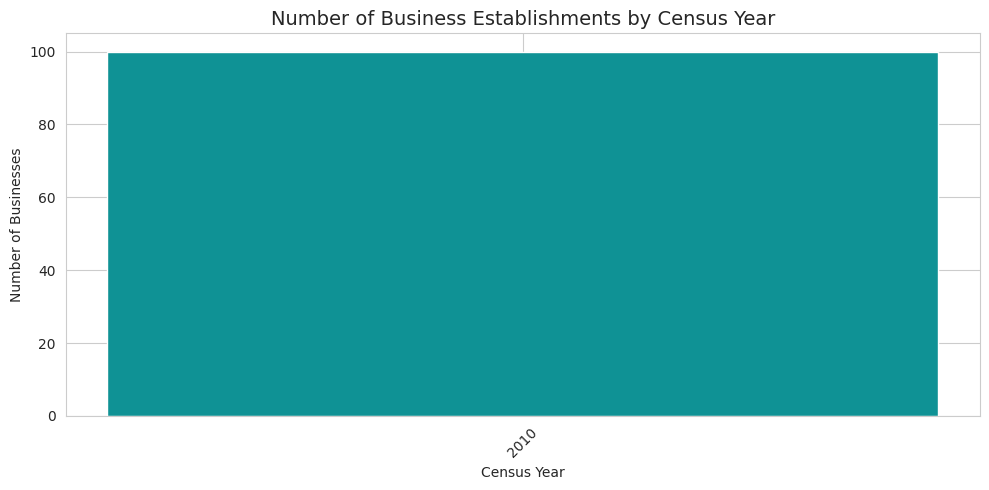

Business count by year plotted.


In [7]:
# Business count by year (if census_year column exists)
if 'census_year' in df_business.columns:
    df_business['census_year'] = df_business['census_year'].astype(str)
    year_counts = df_business.groupby('census_year').size().reset_index(name='business_count')

    plt.figure(figsize=(10, 5))
    plt.bar(year_counts['census_year'], year_counts['business_count'], color=CHAMELEON_COLOR)
    plt.title('Number of Business Establishments by Census Year', fontsize=14)
    plt.xlabel('Census Year')
    plt.ylabel('Number of Businesses')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('business_by_year.png', dpi=150)
    plt.show()
    print("Business count by year plotted.")
else:
    print("census_year column not found - checking available columns:")
    print(df_business.columns.tolist())

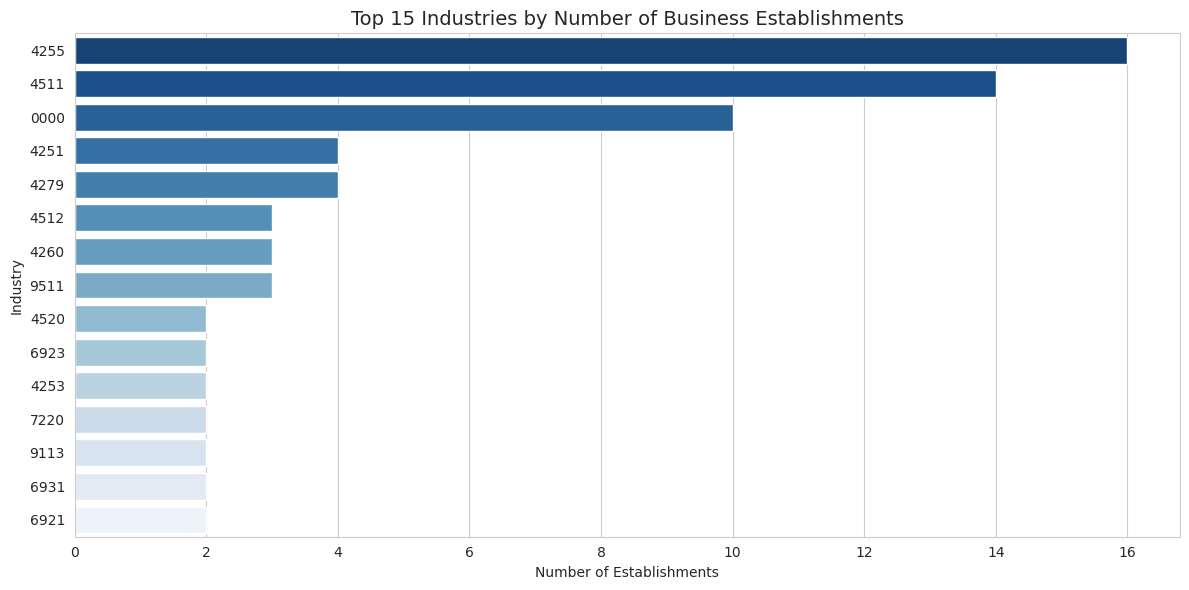

In [8]:
# Top industries by number of establishments
if len(industry_col) > 0:
    top_col = industry_col[0]
    industry_counts = df_business[top_col].value_counts().head(15).reset_index()
    industry_counts.columns = ['industry', 'count']

    plt.figure(figsize=(12, 6))
    sns.barplot(data=industry_counts, x='count', y='industry', palette='Blues_r')
    plt.title('Top 15 Industries by Number of Business Establishments', fontsize=14)
    plt.xlabel('Number of Establishments')
    plt.ylabel('Industry')
    plt.tight_layout()
    plt.savefig('top_industries.png', dpi=150)
    plt.show()
else:
    print("No industry column found. Showing value counts for all columns:")
    print(df_business.dtypes)

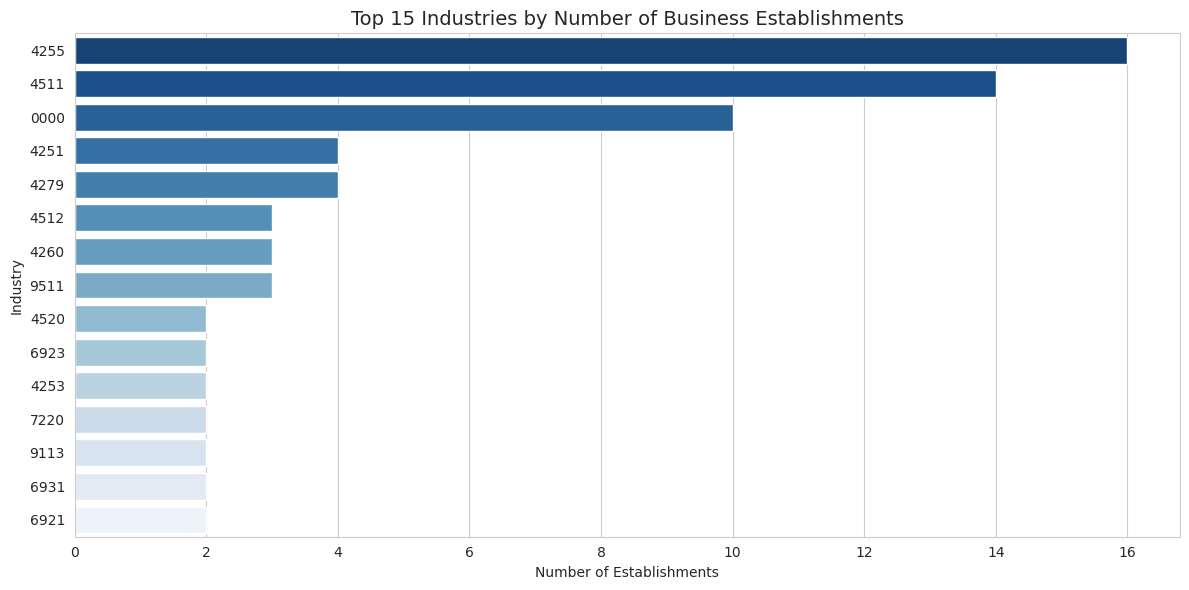

In [9]:
# Top industries by number of establishments
if len(industry_col) > 0:
    top_col = industry_col[0]
    industry_counts = df_business[top_col].value_counts().head(15).reset_index()
    industry_counts.columns = ['industry', 'count']

    plt.figure(figsize=(12, 6))
    sns.barplot(data=industry_counts, x='count', y='industry', palette='Blues_r')
    plt.title('Top 15 Industries by Number of Business Establishments', fontsize=14)
    plt.xlabel('Number of Establishments')
    plt.ylabel('Industry')
    plt.tight_layout()
    plt.savefig('top_industries.png', dpi=150)
    plt.show()
else:
    print("No industry column found. Showing value counts for all columns:")
    print(df_business.dtypes)

<p class="usecase-subsection-header">Step 4: Employment Analysis</p>

In [10]:
# Employment dataset exploration
print("Employment dataset shape:", df_employment.shape)
print("\nColumn names:")
print(df_employment.columns.tolist())
print("\nSample data:")
df_employment.head(10)

Employment dataset shape: (100, 12)

Column names:
['census_year', 'block_id', 'property_id', 'base_property_id', 'clue_small_area', 'trading_name', 'business_address', 'industry_anzsic4_code', 'industry_anzsic4_description', 'longitude', 'latitude', 'point']

Sample data:


,census_year,block_id,property_id,base_property_id,clue_small_area,trading_name,business_address,industry_anzsic4_code,industry_anzsic4_description,longitude,latitude,point
0,2010,55,101193,101193,Melbourne (CBD),Karen Millen,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
1,2010,55,101193,101193,Melbourne (CBD),Arabella Ramsay,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
2,2010,55,101193,101193,Melbourne (CBD),Wayne Cooper,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
3,2010,55,101193,101193,Melbourne (CBD),Leona Edmiston,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
4,2010,55,101193,101193,Melbourne (CBD),Cacao,352 Bourke Street MELBOURNE 3000,4512,Takeaway Food Services,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
5,2010,55,101193,101193,Melbourne (CBD),Digby's Boutique,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
6,2010,55,101193,101193,Melbourne (CBD),Baccini & Hill,Part 350-0 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
7,2010,55,101193,101193,Melbourne (CBD),Veronika Maine,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
8,2010,55,101193,101193,Melbourne (CBD),Brides In Melbourne,338-352 Bourke Street MELBOURNE 3000,4255,Womens Clothing Retailing,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"
9,2010,55,101193,101193,Melbourne (CBD),"Donald Cant, Watts, Corke Pty Limited","Part Level 3, 338-352 Bourke Street MELBOURNE ...",6923,Engineering Design and Engineering Consulting ...,144.963288,-37.813604,"{'lon': 144.963287929, 'lat': -37.81360425}"


In [11]:
# Find employment total column
emp_col = [c for c in df_employment.columns if 'employ' in c.lower() or 'total' in c.lower() or 'jobs' in c.lower()]
print("Employment-related columns:", emp_col)

industry_emp = [c for c in df_employment.columns if 'industry' in c.lower() or 'anzsic' in c.lower()]
print("Industry columns in employment data:", industry_emp)

Employment-related columns: []
Industry columns in employment data: ['industry_anzsic4_code', 'industry_anzsic4_description']


<p class="usecase-subsection-header">Step 5: Key Metrics – Employment-to-Business Ratio</p>

The employment-to-business ratio helps identify industries where businesses tend to be
larger employers versus industries dominated by small or sole-trader businesses.
A high ratio means fewer businesses employ many people (e.g. hospitals, large offices).
A low ratio suggests many small businesses with few employees each.

In [12]:
# This cell will calculate ratios once columns are confirmed from API output above
# Placeholder for ratio analysis - to be completed after column inspection

# Example structure (adapt column names based on actual API output):
# df_merged = pd.merge(df_business_agg, df_employment_agg, on=['industry', 'area'])
# df_merged['employment_ratio'] = df_merged['total_employment'] / df_merged['business_count']
# df_merged['ratio_category'] = pd.cut(df_merged['employment_ratio'],
#                                       bins=[0, 5, 20, 100, float('inf')],
#                                       labels=['Micro', 'Small', 'Medium', 'Large'])

print("Ratio analysis framework defined.")
print("Next step: merge datasets and calculate employment-to-business ratio by industry.")

Ratio analysis framework defined.
Next step: merge datasets and calculate employment-to-business ratio by industry.


<div class="usecase-section-header">Summary and Key Findings</div>

This use case has demonstrated how to:
- Load and explore CLUE Business Establishments and Employment datasets via the City of Melbourne Open Data API
- Perform data cleaning and preprocessing to prepare datasets for analysis
- Conduct exploratory data analysis to identify industry-level and area-level patterns
- Develop initial visualisations showing business density and employment distribution
- Define the employment-to-business ratio metric to identify potential economic gaps

**Next steps for Sprint 2:**
- Complete the dataset merge and ratio calculations across all CLUE small areas
- Build interactive Folium maps showing spatial distribution of employment gaps
- Apply clustering (KMeans) to group areas by economic profile
- Develop forecasting models to project employment trends by industry